# Notebook Downloads Data from FRED & YF
## Combines into single dataframe and saves
### Authors Andy Jiang & Collin McDevitt
### Date 02/21/2026

In [2]:
%pip install neuralforecast yfinance matplotlib pandas numpy statsmodels pmdarima scikit-learn darts setuptools
%pip install --upgrade "packaging<24.0" setuptools

  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
Using cached packaging-26.0-py3-none-any.whl (74 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 23.2
    Uninstalling packaging-23.2:
      Successfully uninstalled packaging-23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.7.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
Using cached packaging-23.2-py3-none-any.whl (53 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are insta

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as pdr

import yfinance as yf
from darts import TimeSeries

from darts.models import NBEATSModel, NHiTSModel

from darts.dataprocessing.transformers import Scaler

from darts.metrics import rmse
import pmdarima as pm
from sklearn.metrics import mean_squared_error

from fredapi import Fred


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error



The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


In [4]:
#initial variable 
start_date = "2003-01-01"
end_date = "2026-01-01"

FRED_API_KEY = "924b7c78199ddb925eba32ca6a863a14"

fred = Fred(api_key=FRED_API_KEY)


In [5]:
df = yf.download(
    ["QQQ", "^VIX"],
    start=start_date,
    end=end_date,
    interval="1d"
)

df_combined = df['Close'].reset_index()


df_combined = df_combined.rename(columns={
    "Date": "ds",
    "QQQ": "y",
    "^VIX": "vix"
})


df_combined['ds'] = df_combined['ds'].dt.normalize()

print(df_combined.head())
print(f"Shape of combined data: {df_combined.shape}")

[*********************100%***********************]  2 of 2 completed

Ticker         ds          y        vix
0      2003-01-02  21.453466  25.389999
1      2003-01-03  21.689964  24.680000
2      2003-01-06  22.230520  24.910000
3      2003-01-07  22.509251  25.129999
4      2003-01-08  21.875776  25.530001
Shape of combined data: (5787, 3)


Train: 4629 days (2003-01-02 → 2021-05-21)
Test : 1158 days (2021-05-24  → 2025-12-31)


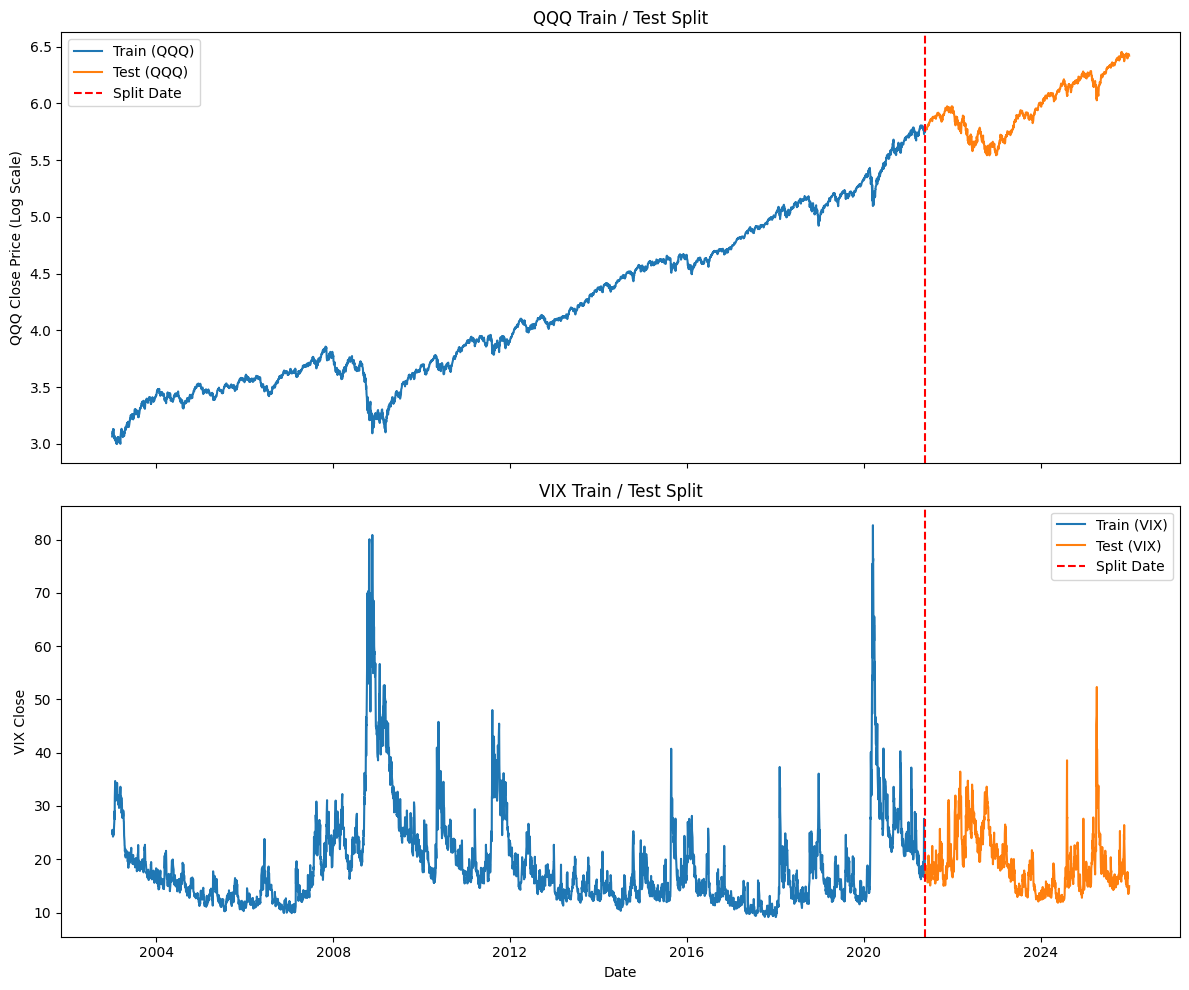

In [12]:
split_ratio = 0.8
split_idx = int(len(df_combined) * split_ratio)


train_df = df_combined.iloc[:split_idx]
test_df  = df_combined.iloc[split_idx:]


split_date = test_df['ds'].iloc[0]


print(f"Train: {len(train_df)} days ({train_df['ds'].min().date()} → {train_df['ds'].max().date()})")
print(f"Test : {len(test_df)} days ({test_df['ds'].min().date()}  → {test_df['ds'].max().date()})")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)


ax1.plot(train_df['ds'], np.log(train_df['y']), label="Train (QQQ)")
ax1.plot(test_df['ds'], np.log(test_df['y']), label="Test (QQQ)")
ax1.axvline(split_date, color="red", linestyle="--", label="Split Date")
ax1.set_title("QQQ Train / Test Split")
ax1.set_ylabel("QQQ Close Price (Log Scale)")
ax1.legend()


ax2.plot(train_df['ds'], train_df['vix'], label="Train (VIX)")
ax2.plot(test_df['ds'], test_df['vix'], label="Test (VIX)")
ax2.axvline(split_date, color="red", linestyle="--", label="Split Date")
ax2.set_title("VIX Train / Test Split")
ax2.set_xlabel("Date")
ax2.set_ylabel("VIX Close")
ax2.legend()

plt.tight_layout()
plt.show()

In [7]:
y_train = train_df['y'].values
y_test  = test_df['y'].values

In [13]:
fred_indicators = {
    "USEPUINDXD": "EPU",
    "UMCSENT": "UMCSENT",
    "ICSA": "JOBLESS",
    "FEDFUNDS": "FEDFUNDS",
    "WLEMUINDXD": "FLOWS",
    "CPIAUCSL": "CPI"
}


macro = pd.DataFrame({
    name: fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
    for ticker, name in fred_indicators.items()
})


macro["inflation_yoy"] = macro["CPI"].pct_change(12) * 100



macro.index = pd.to_datetime(macro.index)
macro = macro.sort_index().ffill()

print(macro.head(10))
print(macro.columns)

               EPU  UMCSENT   JOBLESS  FEDFUNDS   FLOWS    CPI  inflation_yoy
2003-01-01  241.72     82.4       NaN      1.24  317.30  182.6            NaN
2003-01-02  324.67     82.4       NaN      1.24  188.18  182.6            NaN
2003-01-03  357.74     82.4       NaN      1.24  148.90  182.6            NaN
2003-01-04  188.40     82.4  393000.0      1.24  635.94  182.6            NaN
2003-01-05  398.09     82.4  393000.0      1.24  146.09  182.6            NaN
2003-01-06  166.02     82.4  393000.0      1.24  295.76  182.6            NaN
2003-01-07  180.02     82.4  393000.0      1.24  248.74  182.6            NaN
2003-01-08  204.91     82.4  393000.0      1.24   81.20  182.6            NaN
2003-01-09  115.78     82.4  393000.0      1.24  147.64  182.6            NaN
2003-01-10  148.58     82.4  393000.0      1.24  140.03  182.6            NaN
Index(['EPU', 'UMCSENT', 'JOBLESS', 'FEDFUNDS', 'FLOWS', 'CPI',
       'inflation_yoy'],
      dtype='object')


/var/folders/mn/hy84g9197_j0j3cq0ds1y2zm0000gn/T/ipykernel_35607/696696068.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro["inflation_yoy"] = macro["CPI"].pct_change(12) * 100


# Combine FRED & YF Data

In [14]:

macro_reset = macro.reset_index().rename(columns={'index': 'ds'})

master_df = pd.merge(df_combined, macro_reset, on='ds', how='left')


master_df = master_df.bfill()

print(master_df.head())
print(f"\nFinal Master Shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")

#Save the master dataframe to a CSV file for future use
master_df.to_csv("dataframe.csv", index=False)

          ds          y        vix     EPU  UMCSENT   JOBLESS  FEDFUNDS  \
0 2003-01-02  21.453466  25.389999  324.67     82.4  393000.0      1.24   
1 2003-01-03  21.689964  24.680000  357.74     82.4  393000.0      1.24   
2 2003-01-06  22.230520  24.910000  166.02     82.4  393000.0      1.24   
3 2003-01-07  22.509251  25.129999  180.02     82.4  393000.0      1.24   
4 2003-01-08  21.875776  25.530001  204.91     82.4  393000.0      1.24   

    FLOWS    CPI  inflation_yoy  
0  188.18  182.6            0.0  
1  148.90  182.6            0.0  
2  295.76  182.6            0.0  
3  248.74  182.6            0.0  
4   81.20  182.6            0.0  

Final Master Shape: (5787, 10)
Columns: ['ds', 'y', 'vix', 'EPU', 'UMCSENT', 'JOBLESS', 'FEDFUNDS', 'FLOWS', 'CPI', 'inflation_yoy']


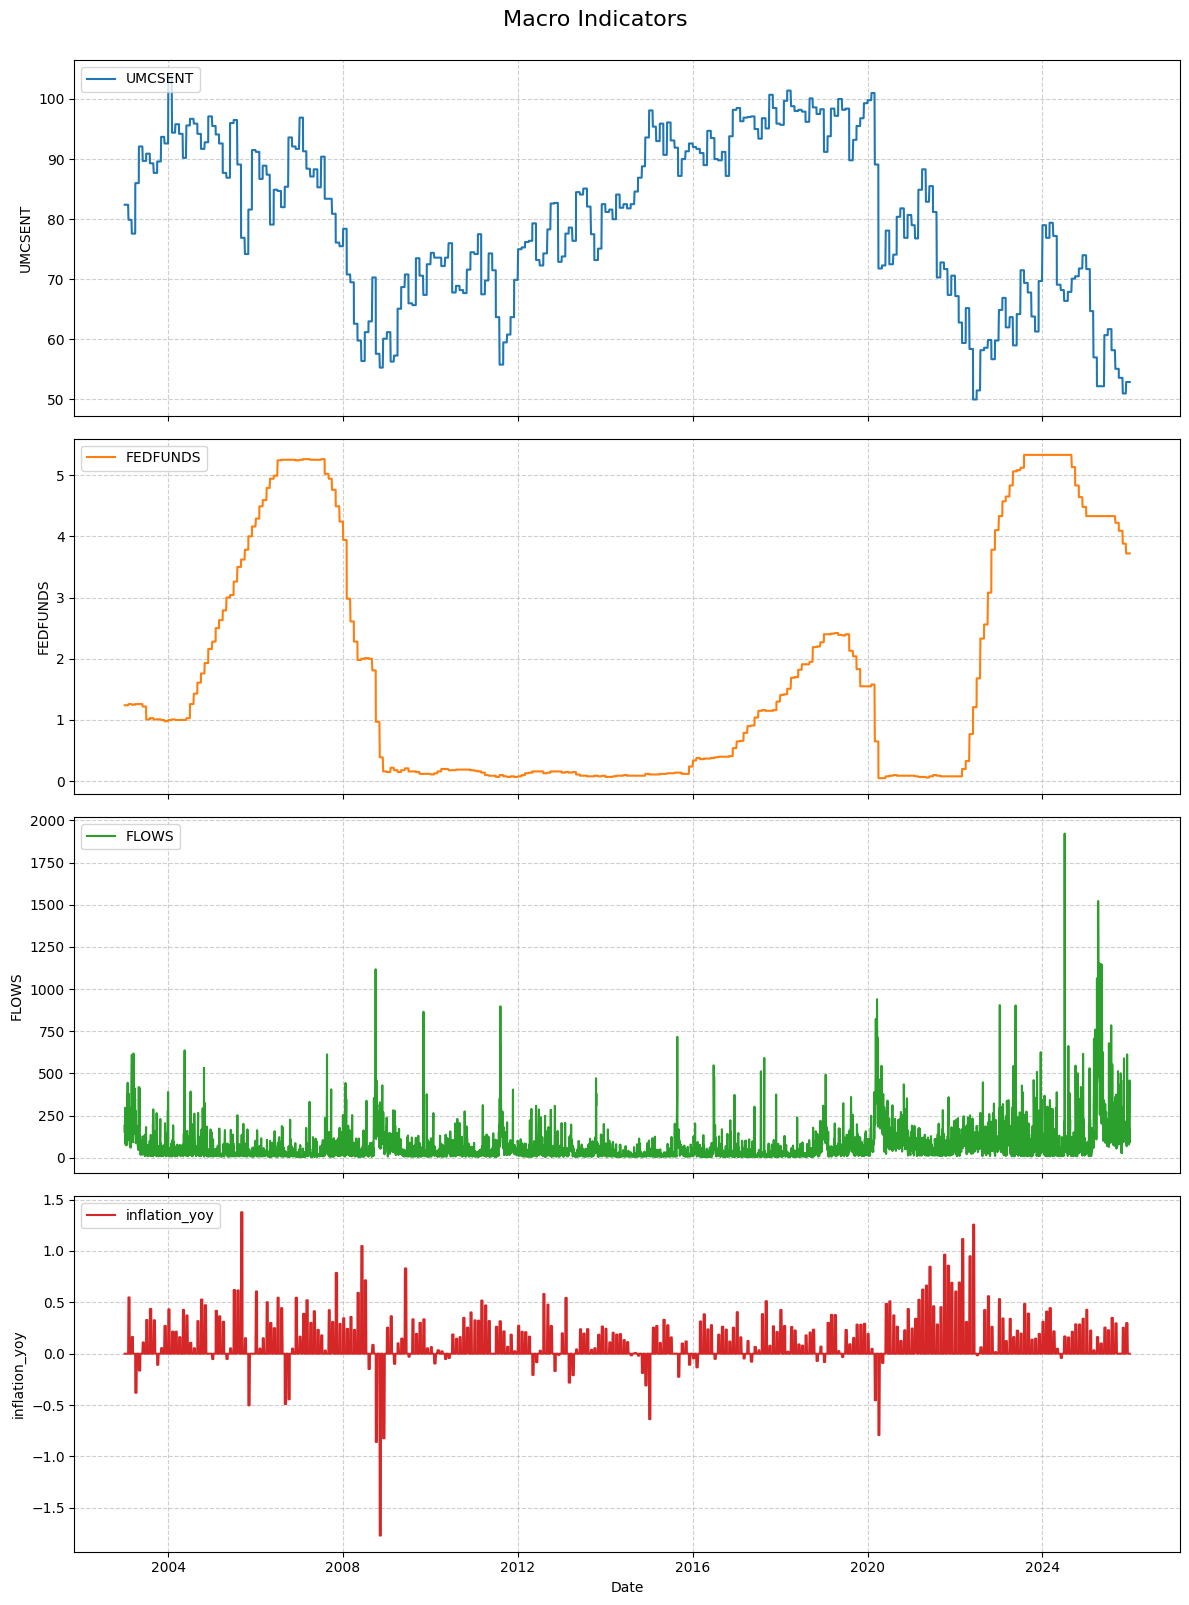

In [ ]:
import matplotlib.pyplot as plt


cols_to_plot = [
     'UMCSENT', 
    'FEDFUNDS', 'inflation_yoy'
]

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(12, 16), sharex=True)


for i, col in enumerate(cols_to_plot):
    axes[i].plot(master_df['ds'], master_df[col], label=col, color=f'C{i}')
    axes[i].set_ylabel(col)
    
    
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    axes[i].legend(loc="upper left")

axes[-1].set_xlabel('Date')
fig.suptitle('Macro Indicators', fontsize=16, y=1.0)


plt.tight_layout()
plt.show()